# SH-DST-03 — predicting day 8, start to finish

Everything in `01_FULL_STORY.md`, as runnable code.

**No data other than the delivered files and signals we generate ourselves from
orbital mechanics is used anywhere in this notebook.**

Run top to bottom. Roughly 5 minutes.

In [ ]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image

import clean, synth, experiments as E, make_figures as F
from clean import COLS
from sw_score import score, swtest, calibrate
from model import predict

pd.set_option("display.width", 150)
print("ready")

ready


---
# Act 1 — What is actually in the box

Six files, five columns, no satellite identifier. We are told only the orbit class —
and that single word turns out to be worth more than all five columns.

In [2]:
for f in ["DATA_GEO_Train.csv", "DATA_MEO_Train.csv", "DATA_MEO_Train2.csv"]:
    d = sih.load(f)
    span = (d.utc_time.max() - d.utc_time.min()).total_seconds() / 86400
    print(f"{f[5:-4]:12s} {len(d):4d} rows over {span:.2f} days   "
          f"{d.utc_time.min()} -> {d.utc_time.max()}")
sih.load("DATA_MEO_Train2.csv").head()

GEO_Train     142 rows over 6.74 days   2025-09-01 06:00:00 -> 2025-09-07 23:41:00
MEO_Train      46 rows over 6.08 days   2025-09-01 14:00:00 -> 2025-09-07 16:00:00
MEO_Train2    143 rows over 6.06 days   2025-09-03 10:11:00 -> 2025-09-09 11:41:00


,utc_time,x_error,y_error,z_error,satclockerror
0,2025-09-03 10:11:00,-0.026800,0.073632,0.078433,0.008539
1,2025-09-03 10:21:00,-0.085093,0.038818,0.082896,-0.006356
2,2025-09-03 10:31:00,-0.098012,0.039264,0.114348,0.011094
3,2025-09-03 10:41:00,-0.107813,0.054688,0.132517,-0.006356
4,2025-09-03 10:51:00,-0.062513,0.020461,0.072511,-0.006356


  wrote figures/f01_raw_data.png


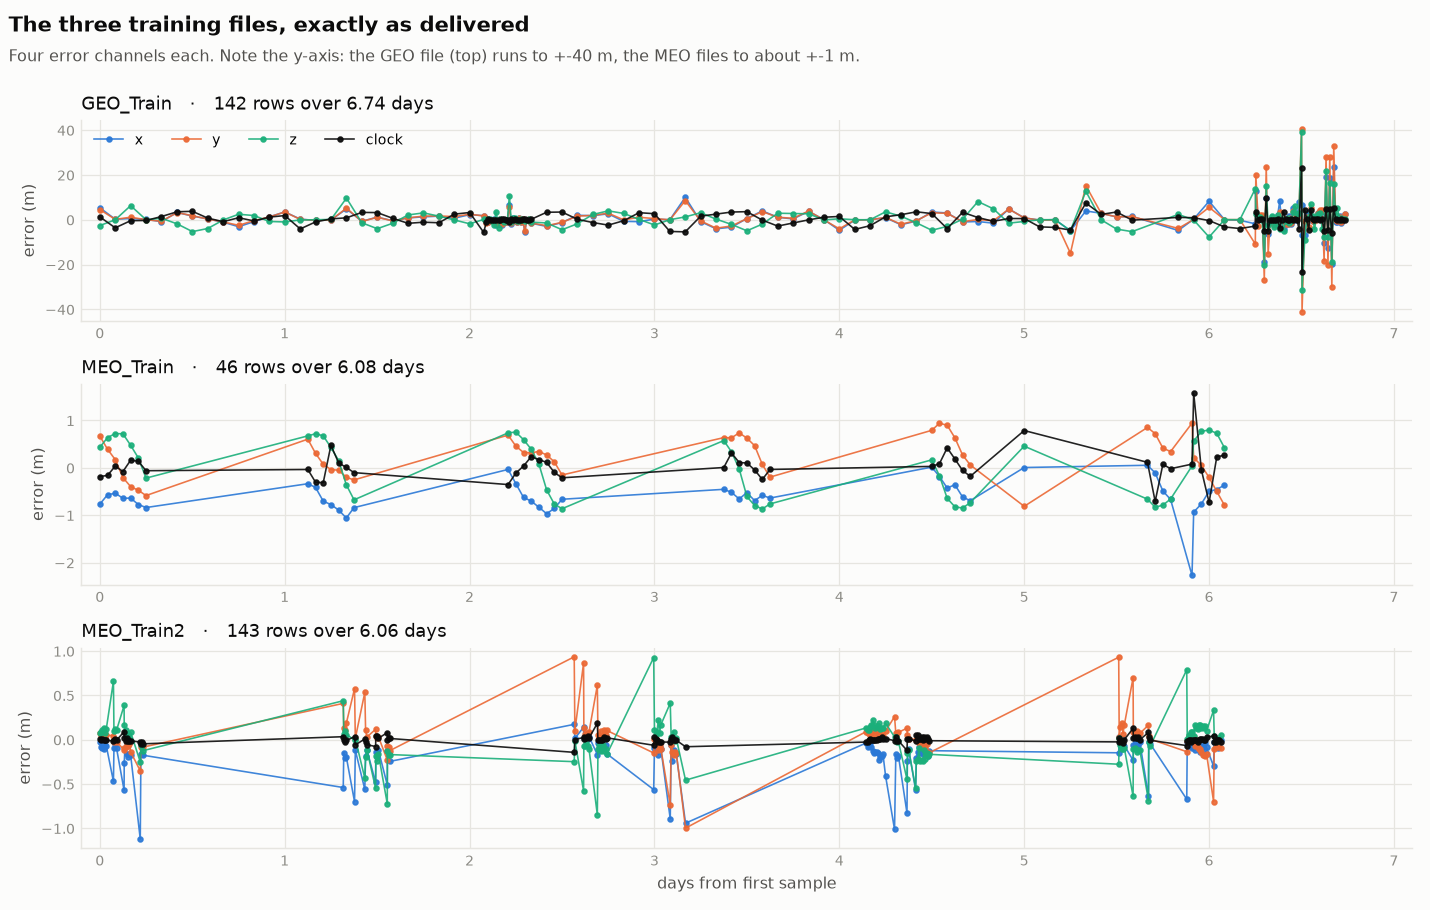

In [3]:
F.f01_raw()
Image('figures/f01_raw_data.png')

## 1.1 Half of every MEO file is duplicated — and removing it is safe

Each MEO file contains **exactly one backwards step in time, and that step spans the
whole file**. The block was written out twice, so de-duplicating is provably lossless
rather than a judgement call.

In [4]:
sih.dup_report()

,file,rows,unique,dropped,backward_steps,block_concat
0,GEO_Test,69,69,0,0,False
1,GEO_Train,142,142,0,0,False
2,MEO_Test,11,6,5,1,True
3,MEO_Test2,30,18,12,1,True
4,MEO_Train,90,46,44,1,True
5,MEO_Train2,244,143,101,1,True


  wrote figures/f03_duplicates.png


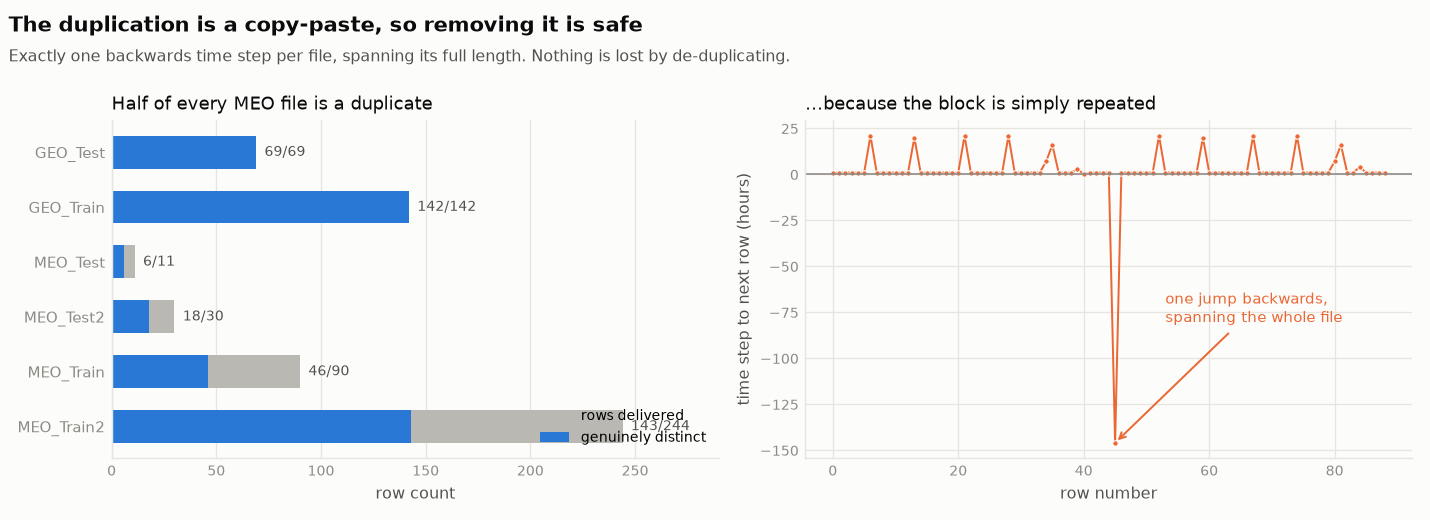

In [5]:
F.f03_duplicates()
Image('figures/f03_duplicates.png')

## 1.2 No file spans seven days

Coverage runs 13%–32%, with gaps up to 26 hours. So consecutive *rows* are not
consecutive *samples* — a trap that made the MEO files look like pure noise until we
masked to genuinely adjacent readings.

  wrote figures/f02_coverage.png


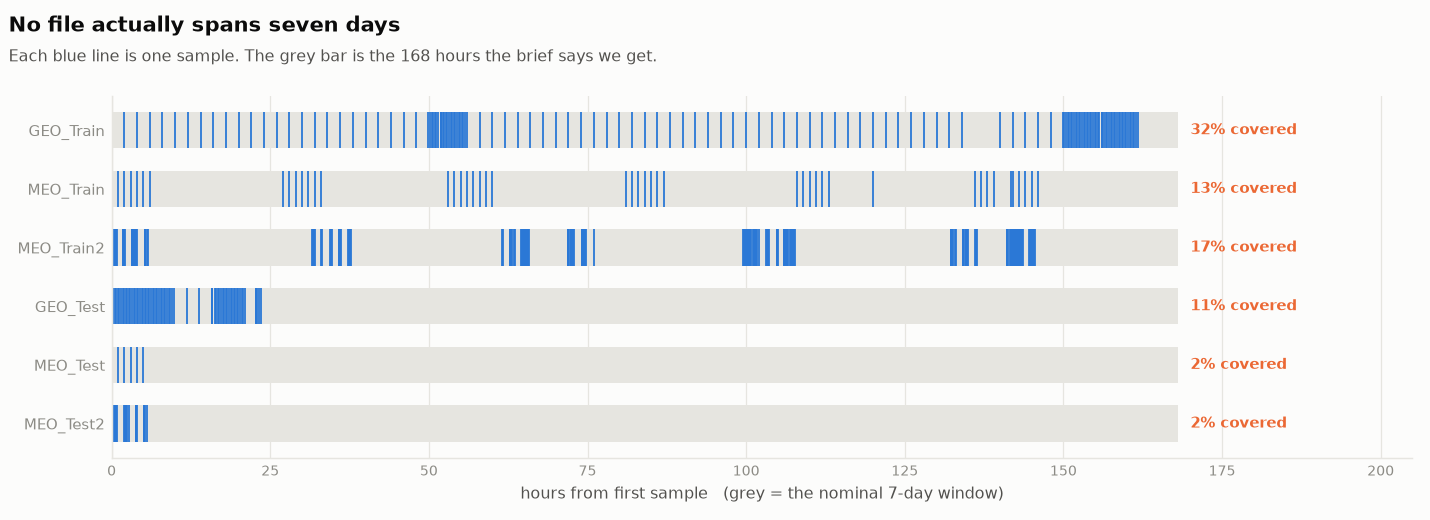

In [6]:
F.f02_coverage()
Image('figures/f02_coverage.png')

## 1.3 Day 8 is not drawn from the same process as days 1–7

  wrote figures/f04_distribution_shift.png


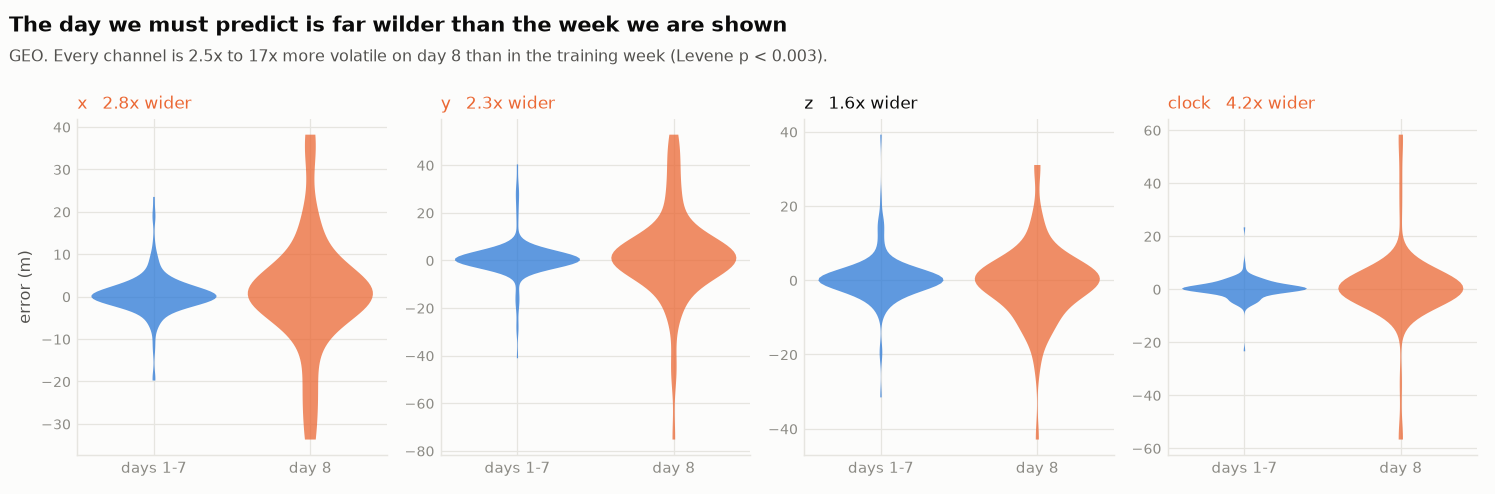

In [7]:
F.f04_shift()
Image('figures/f04_distribution_shift.png')

## 1.4 The volatility is a ramp, not a glitch

Broken down day by day, the GEO training file gets steadily wilder — roughly doubling
each day from day 5 — and day 8 continues the same climb.

A reasonable suggestion is to drop the wild final day as an outlier. We test that
below: every variant lands within noise of every other. **The training data was never
the limiting factor.**

In [8]:
E.exp_ramp()


EXPERIMENT 6 -- GEO_Train volatility, day by day (day 8 = the test file)
        n  x_error  y_error  z_error  satclockerror
day                                                
1    12.0    2.180    1.898    3.056          1.986
2    12.0    1.641    1.741    3.372          2.219
3    33.0    2.076    1.895    2.555          1.635
4    12.0    3.667    3.223    2.568          3.148
5    12.0    2.639    2.366    3.495          2.720
6    10.0    2.895    7.322    5.130          3.608
7    51.0    7.780   14.007   10.215          5.563
8    69.0   13.930   19.761   10.495         15.896

  y_error spread grows 10.4x from day 1 to day 8.


,n,x_error,y_error,z_error,satclockerror
day,,,,,
1,12.0,2.180046,1.897742,3.055578,1.985787
2,12.0,1.640716,1.741436,3.372269,2.219337
3,33.0,2.075945,1.894909,2.554894,1.634802
4,12.0,3.667464,3.223427,2.568125,3.147596
5,12.0,2.638996,2.366379,3.495169,2.720157
6,10.0,2.895019,7.321949,5.129754,3.608442
7,51.0,7.779502,14.007289,10.215002,5.563251
8,69.0,13.930277,19.761213,10.494602,15.895887


In [9]:
tr, te, orb = sih.load_pair("GEO"); T = te[COLS].reset_index(drop=True)
tr = tr.copy(); tr["day"] = (tr.utc_time - tr.utc_time.min()).dt.total_seconds() // 86400
rows = []
for lbl, sub in [("all 7 days", tr), ("drop day 7", tr[tr.day < 6]),
                 ("drop days 6-7", tr[tr.day < 5]), ("only days 6-7", tr[tr.day >= 5])]:
    s2 = sub.drop(columns="day")
    if len(s2) < 20:
        continue
    P = predict(s2, te.utc_time, orbit=orb)[COLS].reset_index(drop=True)
    _, s = score(P - T)
    rows.append({"training data": lbl, "n": len(s2), "RMS": s["rms"], "W": s["W"]})
pd.DataFrame(rows)

,training data,n,RMS,W
0,all 7 days,142,14.961640,0.771505
1,drop day 7,91,14.979790,0.776460
2,drop days 6-7,81,14.961154,0.777646
3,only days 6-7,61,14.952579,0.775085


  wrote figures/f05_volatility_ramp.png


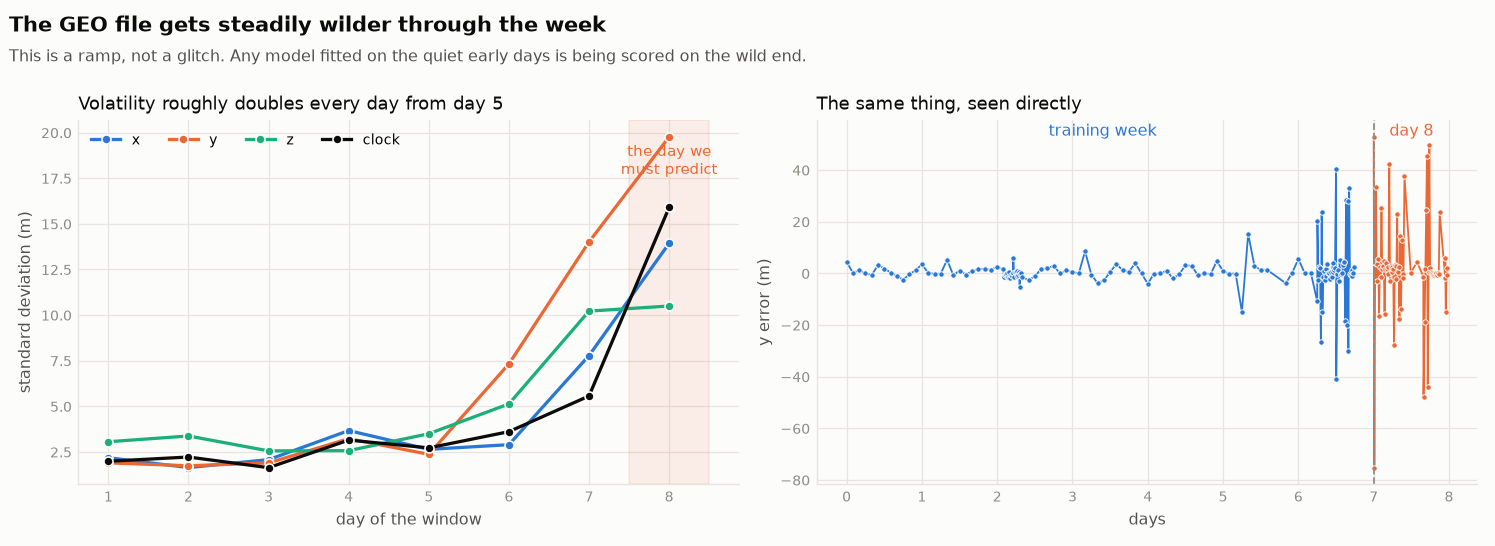

In [10]:
F.f05_ramp()
Image('figures/f05_volatility_ramp.png')

---
# Act 1.5 — We treated it as a machine-learning problem first

Before introducing any physics: 400 windows, ~27,000 training rows, 19 engineered
features, six standard regressors, tested on windows never seen in training.

**The task is stated exactly.** Day 8 lies up to 24 hours beyond the last observation,
so the models cannot lean on "what happened five minutes ago" — that information does
not exist at prediction time.

*(About a minute to run.)*

In [11]:
ml = E.exp_ml_fails(n_windows=400)


EXPERIMENT 8 -- ordinary ML on the actual task (predict day 8, not the next sample)
   400 windows, 26,784 training rows, 19 features
                    model     kind      rms
  SMART-HORIZON (physics)  physics   0.3794
        Gradient boosting  learned   0.4206
            Random forest  learned   0.4255
         Ridge regression  learned   0.4320
     Neural network (MLP)  learned   0.4460
   predict the 7-day mean baseline   0.4516
Support vector regression  learned   0.4545
     k-nearest neighbours  learned   0.5146
   predict the last value baseline   0.6845
             predict zero baseline   0.9893

  best learner 0.4206   best trivial baseline 0.4516   ->  learning HELPS


  wrote figures/f21_ml_plateau.png


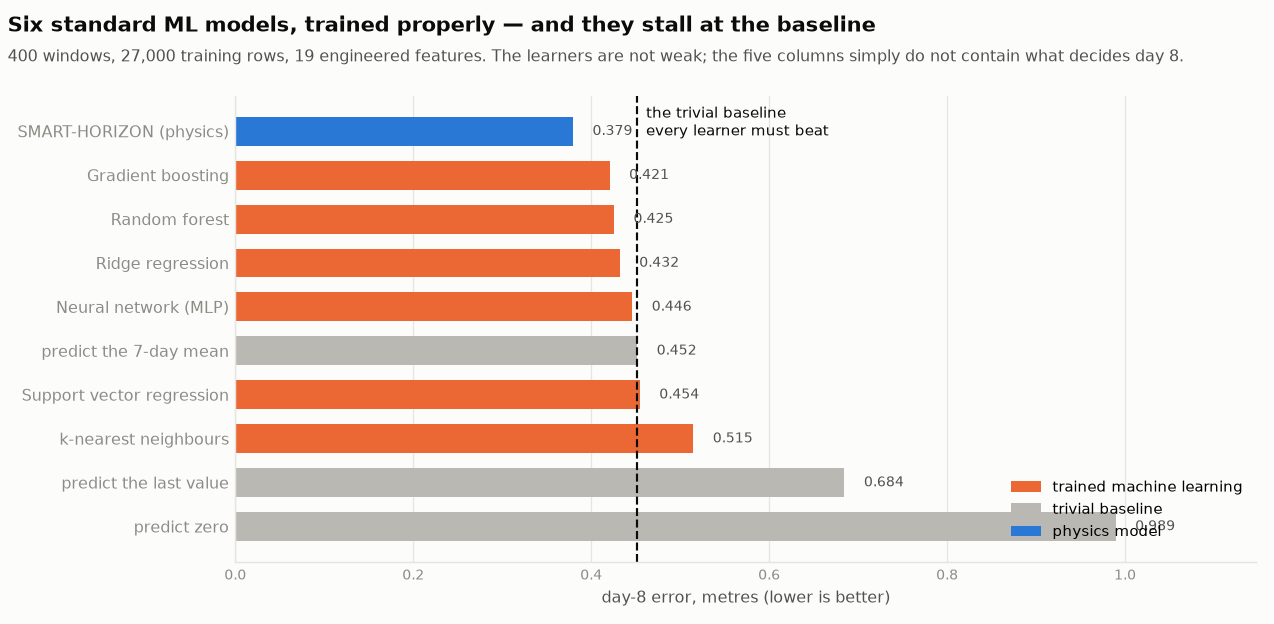

In [12]:
F.f21_ml_plateau()
Image('figures/f21_ml_plateau.png')

### Why they stall

The models are not underpowered. **The inputs do not determine the output.**

What decides day 8 is where the satellite sits in its orbit, which constellation it
belongs to, and when the ground segment last uploaded fresh navigation data. **None of
those are columns in the file.** A supervised learner asked to infer a quantity that
shares almost no information with anything it can see will correctly learn almost
nothing.

So the orbital rhythm is **not a pattern hiding in the data — it is information from
outside it, which we have to supply.** That is the argument for everything that
follows, and the same physics model scores 0.379 against the best learner's 0.421 on
the identical held-out windows.

---
# Act 2 — What physics says must be true

Derivations with plain-English explanations are in `PHYSICS.md`. Two results drive the
model:

1. A geosynchronous satellite repeats every **sidereal day**, 86164 s — not 24 h.
2. In Earth-fixed coordinates x and y are multiplied by the Earth's rotation, which
   splits one rhythm into **two beat periods**. The z axis is the rotation axis, so it
   is untouched and keeps the orbital period.

In [13]:
print(f"{'constellation':14s} {'T (h)':>7s}   x and y appear at (h)")
for k, T in synth.ORBITAL_PERIOD.items():
    b = synth.beat_periods(T)
    print(f"{k:14s} {T/3600:7.2f}   " + ", ".join(f"{x/3600:.2f}" for x in b))
print(f"\n{'GEO':14s} {synth.T_SID/3600:7.2f}   "
      f"(T = T_sid, so the beats collapse onto the sidereal day)")
print(f"\na 7-day window holds {7*86400/synth.T_SID:.2f} sidereal days")

constellation    T (h)   x and y appear at (h)
GPS              11.97   7.98, 23.93
GALILEO          14.05   8.85, 34.00
BEIDOU           12.89   8.38, 27.92

GEO              23.93   (T = T_sid, so the beats collapse onto the sidereal day)

a 7-day window holds 7.02 sidereal days


  wrote figures/f06_beat_frequencies.png


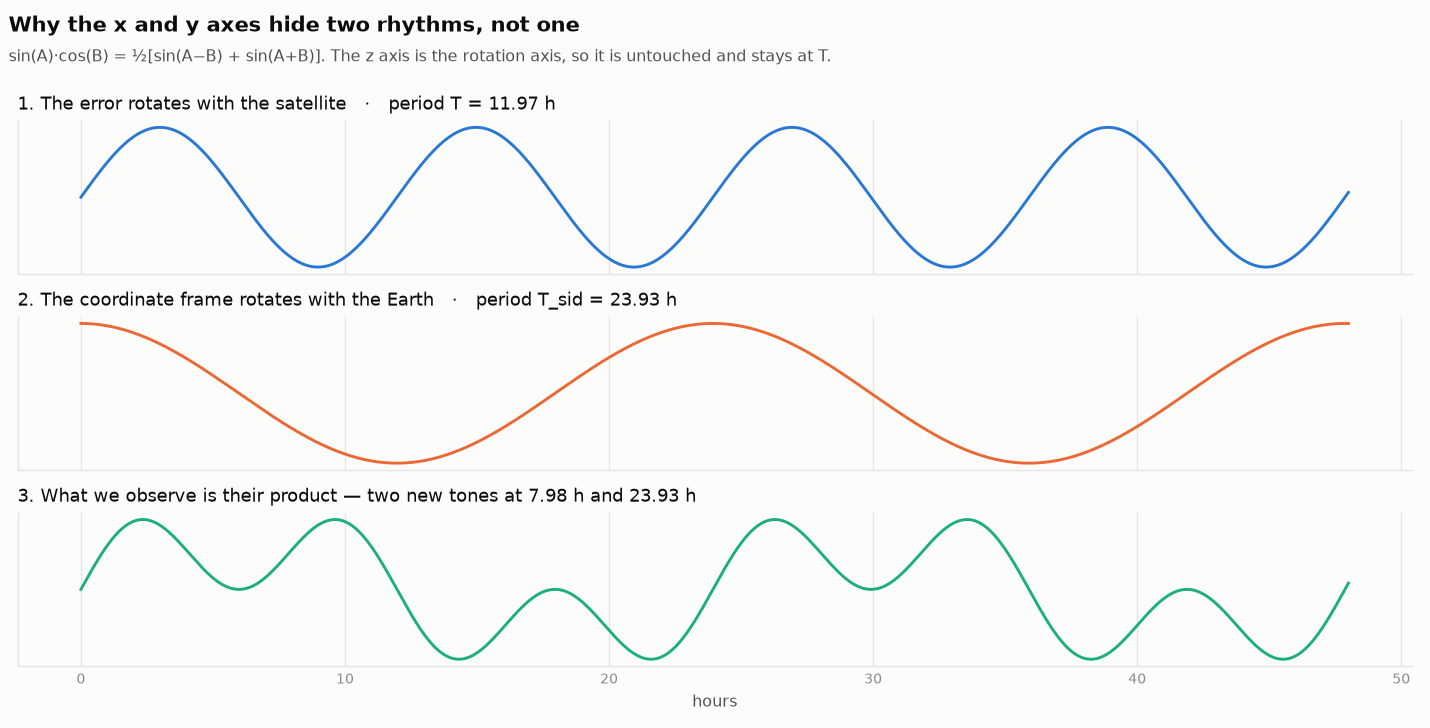

In [14]:
F.f06_beat()
Image('figures/f06_beat_frequencies.png')

## 2.1 Checking the physics against their own data

The honest test: place the physics-predicted periods on a chart of the delivered data
*before* looking at it.

MEO peaks exactly on the predicted band. **The GEO file does not** — its dominant
rhythm is near 12 h, which no geostationary satellite has. That is the first
independent sign the GEO file is not what it claims to be, and it arrives from a
completely different direction than the evidence in Act 4.

  wrote figures/f07_periodogram.png


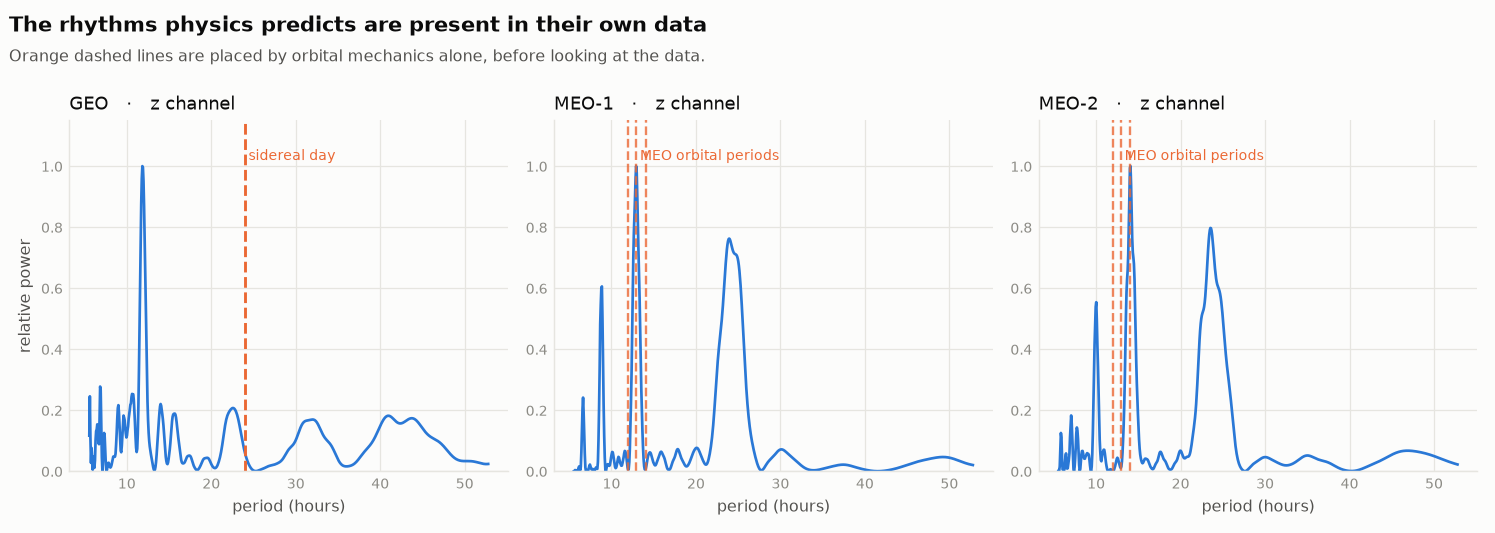

In [15]:
F.f07_periodogram()
Image('figures/f07_periodogram.png')

## 2.2 The clock is a different kind of thing

A random walk plus step resets. No daily rhythm exists to find, so the model is
**forbidden** from looking for one — giving it that freedom makes results worse.

In [16]:
d = sih.load("DATA_MEO_Train2.csv")
n_dist = d.satclockerror.round(9).nunique()
print(f"MEO_Train2: {len(d)} rows but only {n_dist} distinct clock values")
print(f"the most common value repeats "
      f"{d.satclockerror.round(9).value_counts().iloc[0]} times")

MEO_Train2: 143 rows but only 70 distinct clock values
the most common value repeats 17 times


  wrote figures/f08_clock_random.png


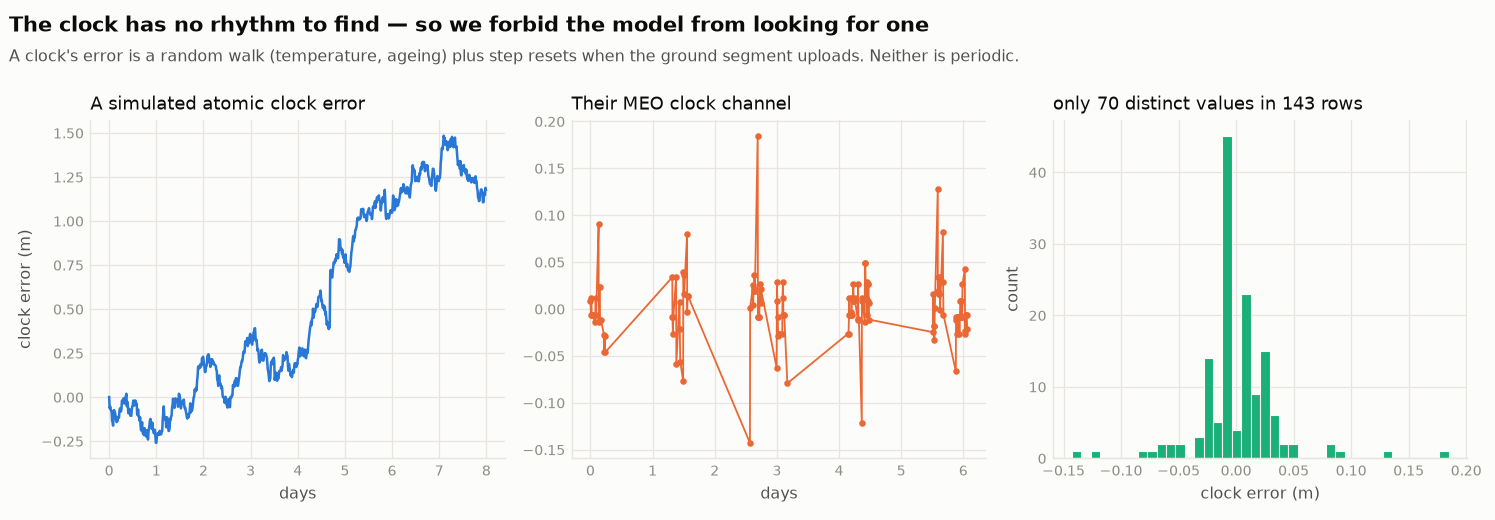

In [17]:
F.f08_clock()
Image('figures/f08_clock_random.png')

---
# Act 3 — The model, and how we validated it

A regularised regression onto a basis of orbital harmonics, in three layers: physics
fixes which rhythms are admissible, the caller's own held-out day 7 picks the basis,
and ridge regression fits the coefficients.

  wrote figures/f22_how_it_works.png


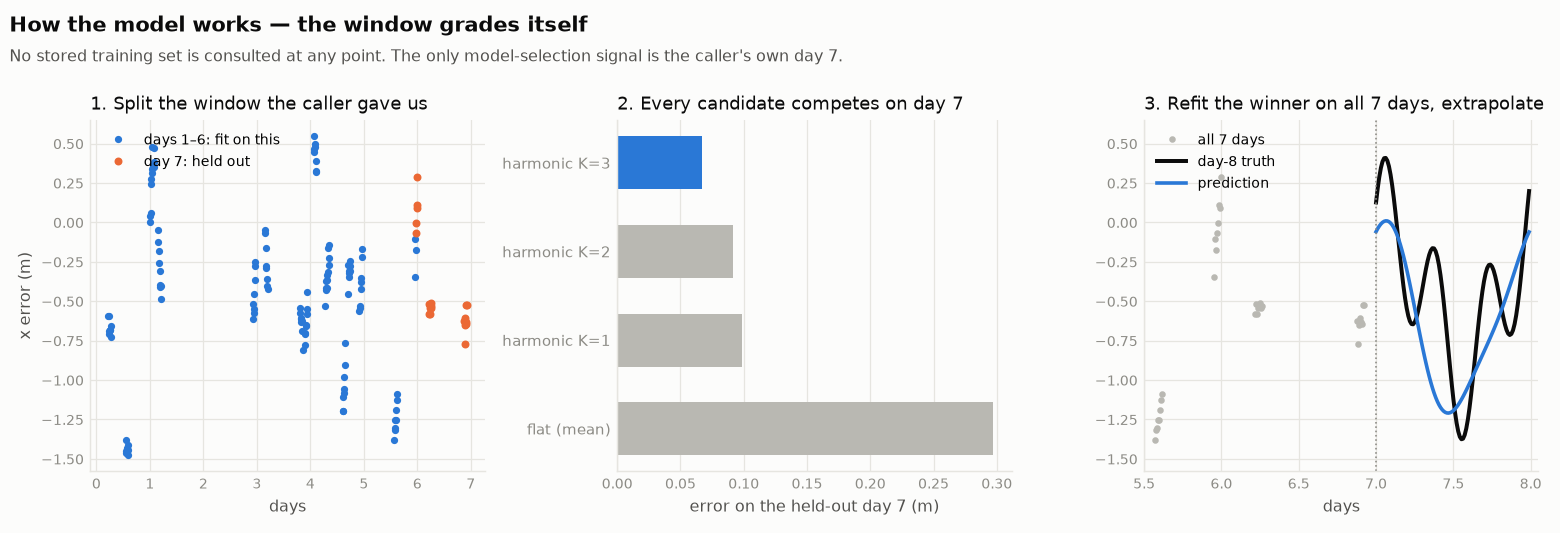

In [18]:
F.f22_how_it_works()
Image('figures/f22_how_it_works.png')

## 3.1 Generating our own data

Three windows cannot show that anything works, and we were asked directly whether we
could generate data. Every term is a documented physical effect, sampled at the
delivered files' own irregular timestamps and gaps.

  wrote figures/f09_synthesis.png


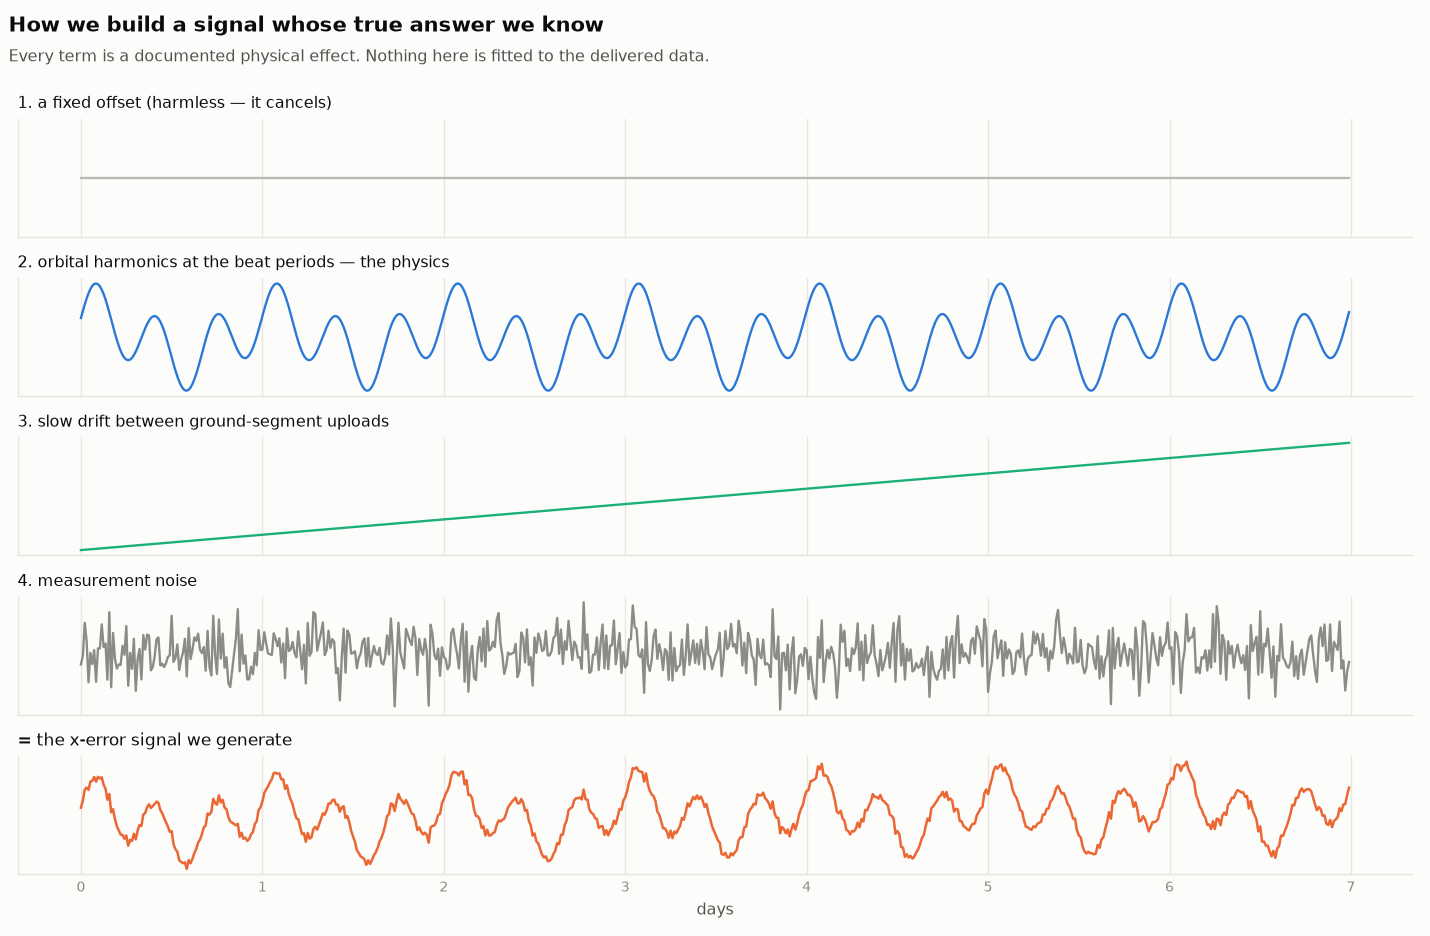

In [19]:
F.f09_synth_build()
Image('figures/f09_synthesis.png')

In [20]:
tr, q, truth, meta = synth.make_window("MEO", seed=1)
print(f"one generated window: {len(tr)} training rows, {len(q)} day-8 query times")
tr.head()

one generated window: 173 training rows, 96 day-8 query times


,utc_time,x_error,y_error,z_error,satclockerror
0,2025-09-01 05:11:23.098294859,0.387752,-0.007663,-0.978202,-0.019030
1,2025-09-01 05:20:40.462189339,0.421364,0.003040,-0.971385,-0.131327
2,2025-09-01 05:30:07.420833999,0.314545,-0.017726,-0.835369,-0.008948
3,2025-09-01 05:39:19.840416728,0.150820,0.003236,-0.782674,-0.010436
4,2025-09-01 05:48:58.917361580,0.245970,-0.077662,-0.799687,-0.043977


## 3.2 Hide day 8, ask the model for it, compare against the truth we planted

The model has never seen the answer.

  wrote figures/f10_recovery_examples.png


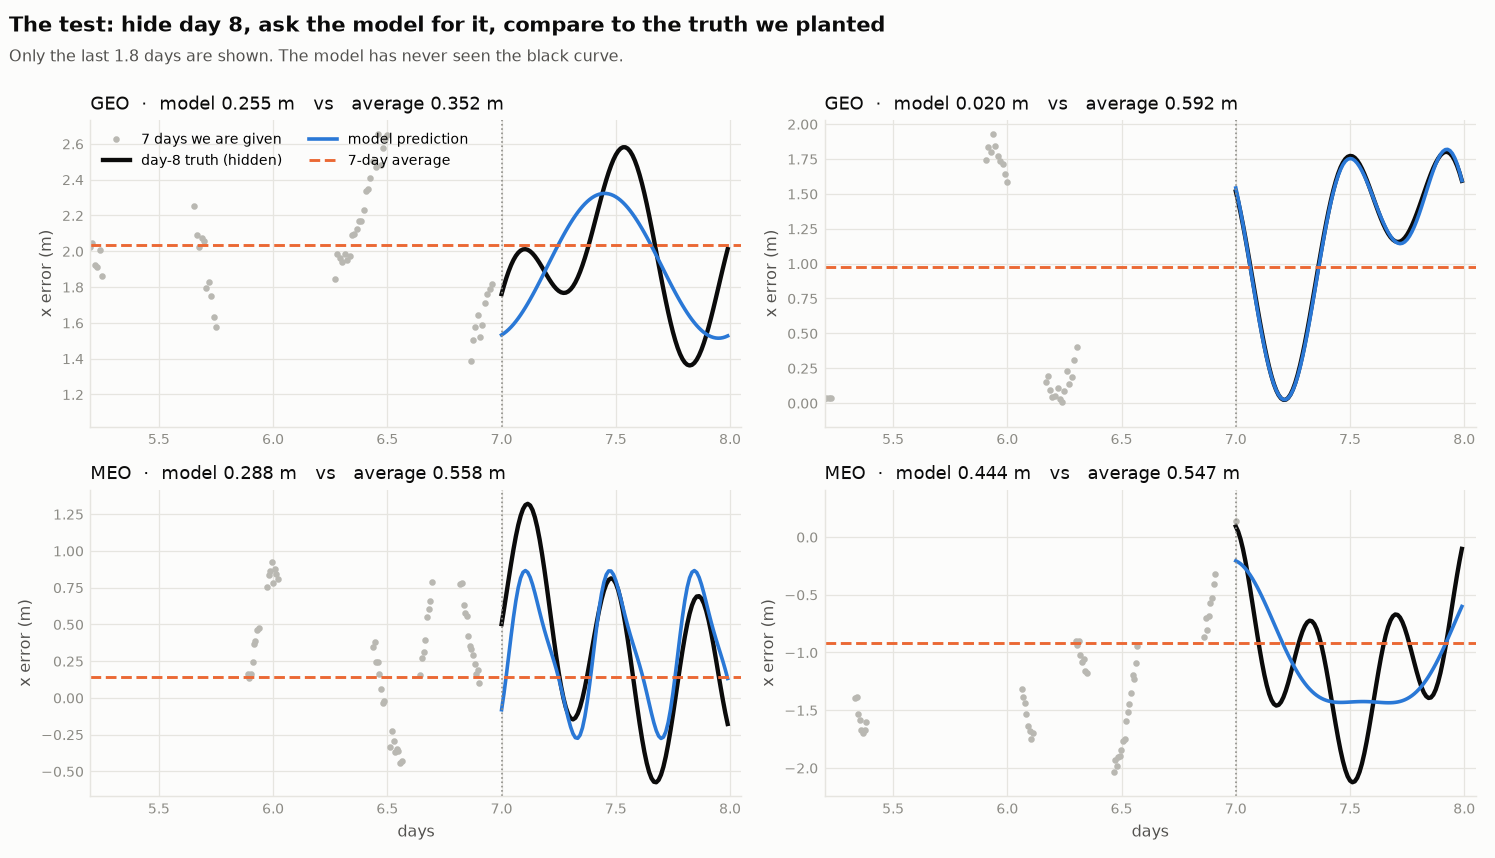

In [21]:
F.f10_recovery_example()
Image('figures/f10_recovery_examples.png')

In [22]:
rec = E.exp_recovery(n=60)

EXPERIMENT 1 -- recovery of a known day 8 (60 windows per class)
         zero         window_mean           model        
         mean     std        mean     std    mean     std
orbit                                                    
GEO    0.7966  0.2121      0.4200  0.0581  0.1609  0.0847
MEO    0.7614  0.2012      0.4164  0.0578  0.3649  0.0915

  GEO    79.8% better than doing nothing   beats the 7-day average in 100% of windows
  MEO    52.1% better than doing nothing   beats the 7-day average in 77% of windows


  wrote figures/f11_recovery_distribution.png


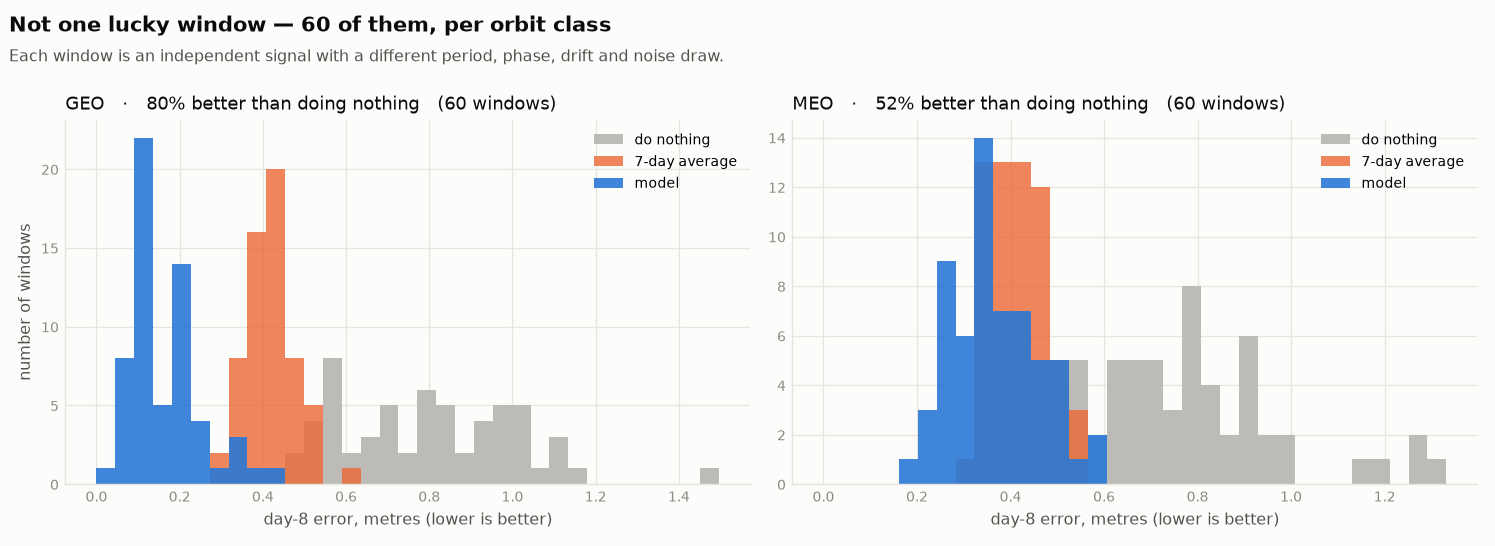

In [23]:
F.f11_recovery_dist()
Image('figures/f11_recovery_distribution.png')

## 3.3 Stress tests

Noise: it degrades gracefully. The sign artefact: catastrophic at one row in ten.

In [24]:
sens = E.exp_sensitivity(n=30)


EXPERIMENT 2 -- sensitivity: what degrades the model, and how fast

  artifact:
            zero   model  % better
   value                          
   0.00   0.7568  0.3690   51.2376
   0.10   0.7568  2.9919 -295.3264
   0.20   0.7568  4.5165 -496.7758
   0.35   0.7568  5.9018 -679.8100
   0.50   0.7568  6.0475 -699.0630

  noise:
            zero   model  % better
   value                          
   0.01   0.7568  0.3690   51.2439
   0.05   0.7568  0.3690   51.2376
   0.15   0.7568  0.3672   51.4836
   0.40   0.7568  0.3875   48.8047
   1.00   0.7568  0.4966   34.3823


  wrote figures/f12_sensitivity.png


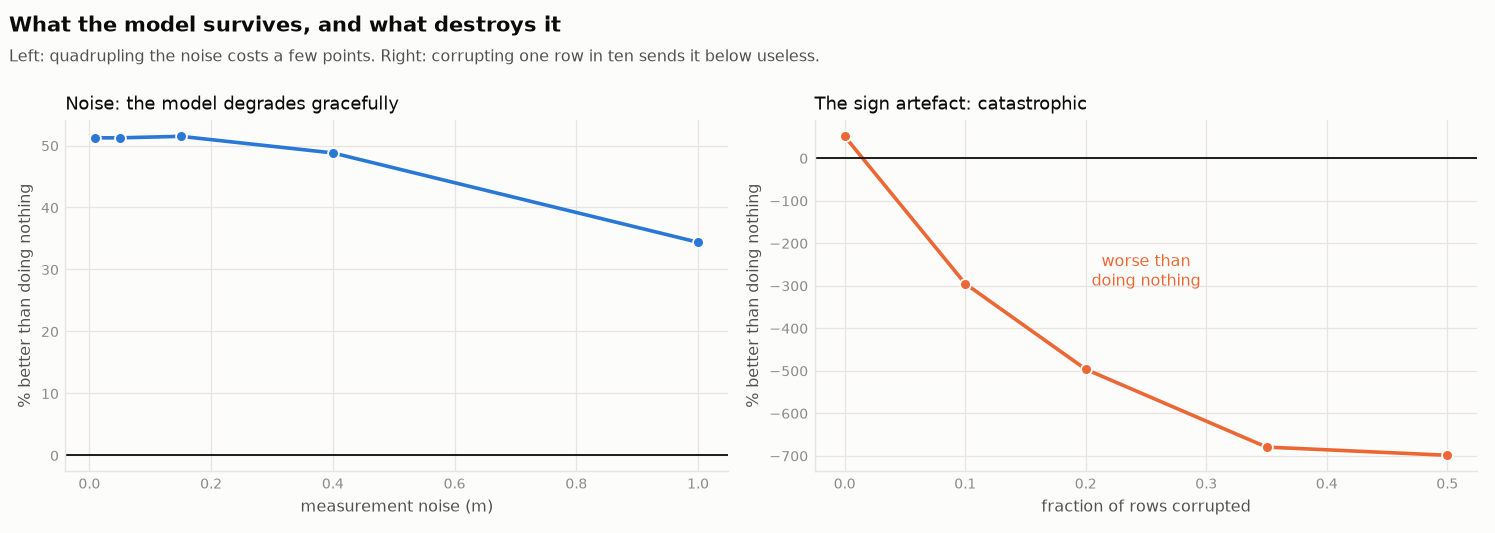

In [25]:
F.f12_sensitivity()
Image('figures/f12_sensitivity.png')

---
# Act 4 — Results on the delivered data

In [26]:
res = E.exp_sih()


EXPERIMENT 7 -- the model on the delivered PS-08 files
pair                  GEO   MEO-1   MEO-2
method                                   
7-day average     14.9481  0.3276  0.1440
CHEAT: test mean  14.9113  0.2105  0.1364
SMART-HORIZON     14.9616  0.1902  0.1334
do nothing        14.9560  0.4437  0.1639
last value        14.9642  0.4266  0.1739

Shapiro-Wilk W (their Priority 1):
pair                 GEO   MEO-1   MEO-2
method                                  
7-day average     0.7708  0.8840  0.7898
CHEAT: test mean  0.7708  0.8840  0.7898
SMART-HORIZON     0.7715  0.9067  0.7977
do nothing        0.7708  0.8840  0.7898
last value        0.7708  0.8840  0.7898


  wrote figures/f14_results.png


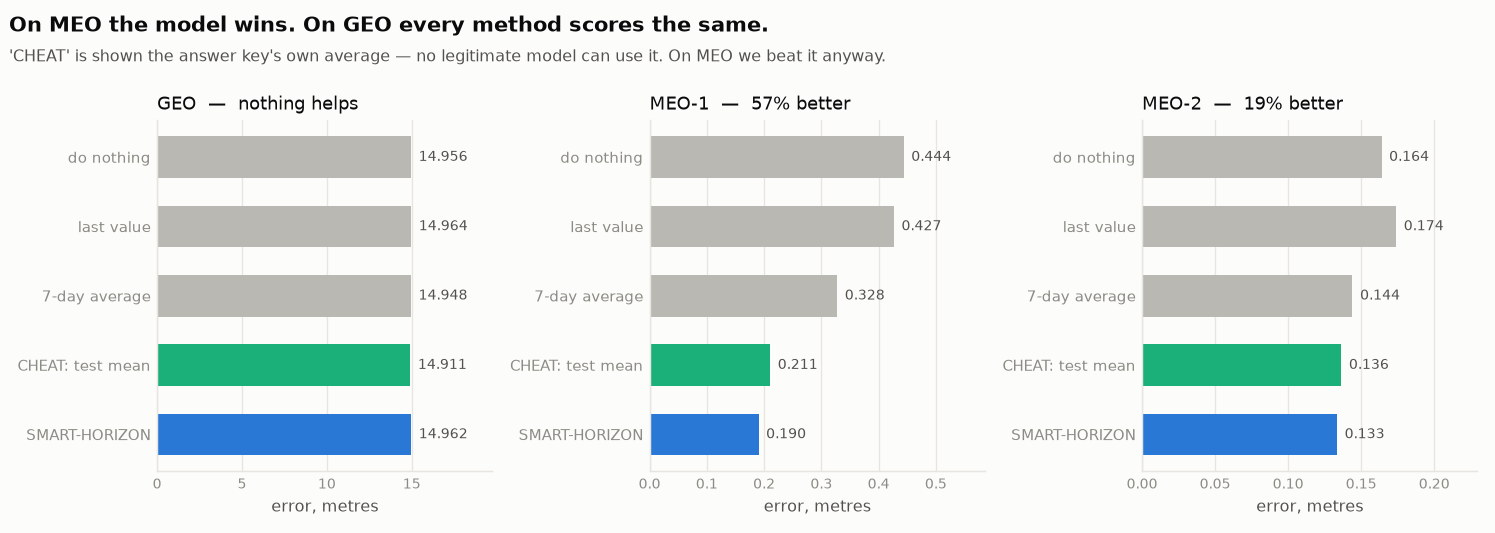

In [27]:
F.f14_sih_results()
Image('figures/f14_results.png')

  wrote figures/f15_meo_predictions.png


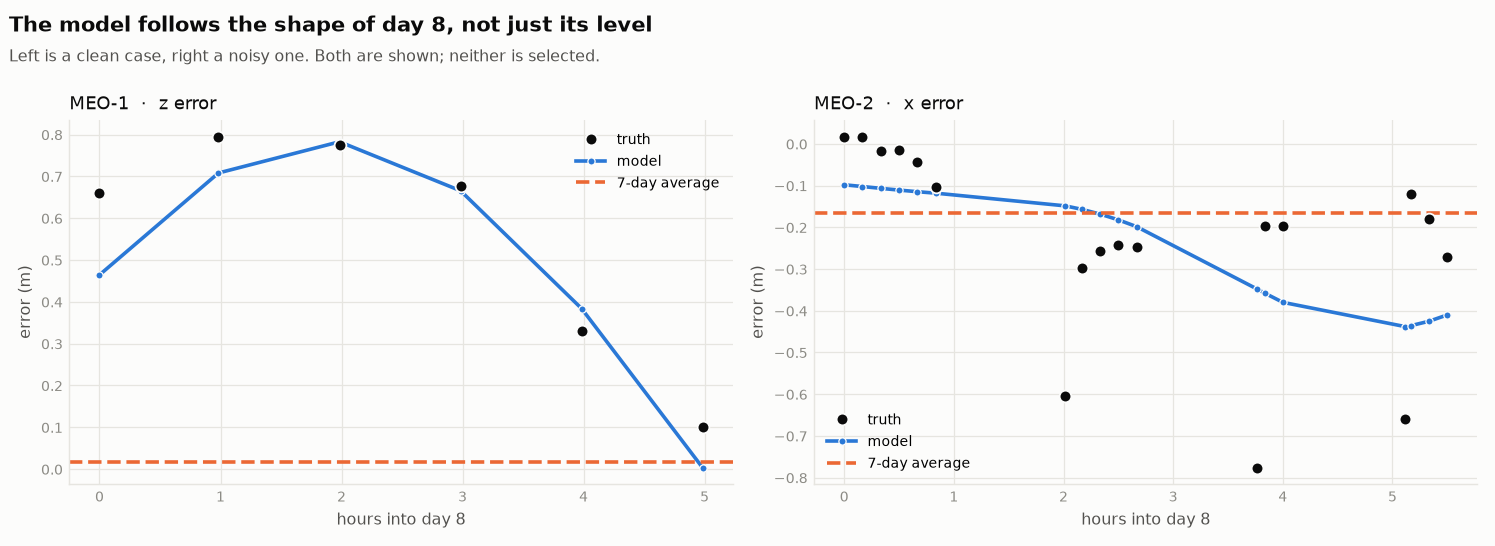

In [28]:
F.f15_meo_pred()
Image('figures/f15_meo_predictions.png')

## 4.1 Sixteen methods, ranked using only the delivered data

Three windows are far too few to benchmark on day 8 — but every window contains its own
held-out day. Fit on days 1–6, score on day 7. Fair, self-contained, and exactly the
signal the model itself uses.

In [29]:
bench = E.exp_benchmark()


EXPERIMENT 4 -- method benchmark inside the delivered data
   (fit days 1-6, score day 7; no outside data used)
pair                 GEO   MEO-1   MEO-2  MEO avg
method                                           
SMART-HORIZON     9.2429  0.3816  0.1737   0.2777
median            9.1564  0.6100  0.1613   0.3857
mean              9.1472  0.6060  0.1671   0.3866
ewma 2d           9.1468  0.6227  0.1676   0.3952
mean last 3d      9.1411  0.6240  0.1667   0.3954
ewma 1d           9.1506  0.6390  0.1688   0.4039
mean last 2d      9.1401  0.6465  0.1641   0.4053
harmonic K=1      9.1799  0.6540  0.1780   0.4160
mean last 1d      9.1411  0.6640  0.1692   0.4166
harmonic K=3      9.3122  0.6532  0.1889   0.4211
harmonic K=2      9.2709  0.6577  0.1848   0.4213
zero              9.1598  0.6858  0.1662   0.4260
linear trend      9.1450  0.7390  0.1700   0.4545
quadratic trend   9.2376  0.7447  0.1913   0.4680
last value        9.5851  0.9395  0.1865   0.5630
seasonal naive   10.8335  0.9395  0.1

  wrote figures/f20_benchmark.png


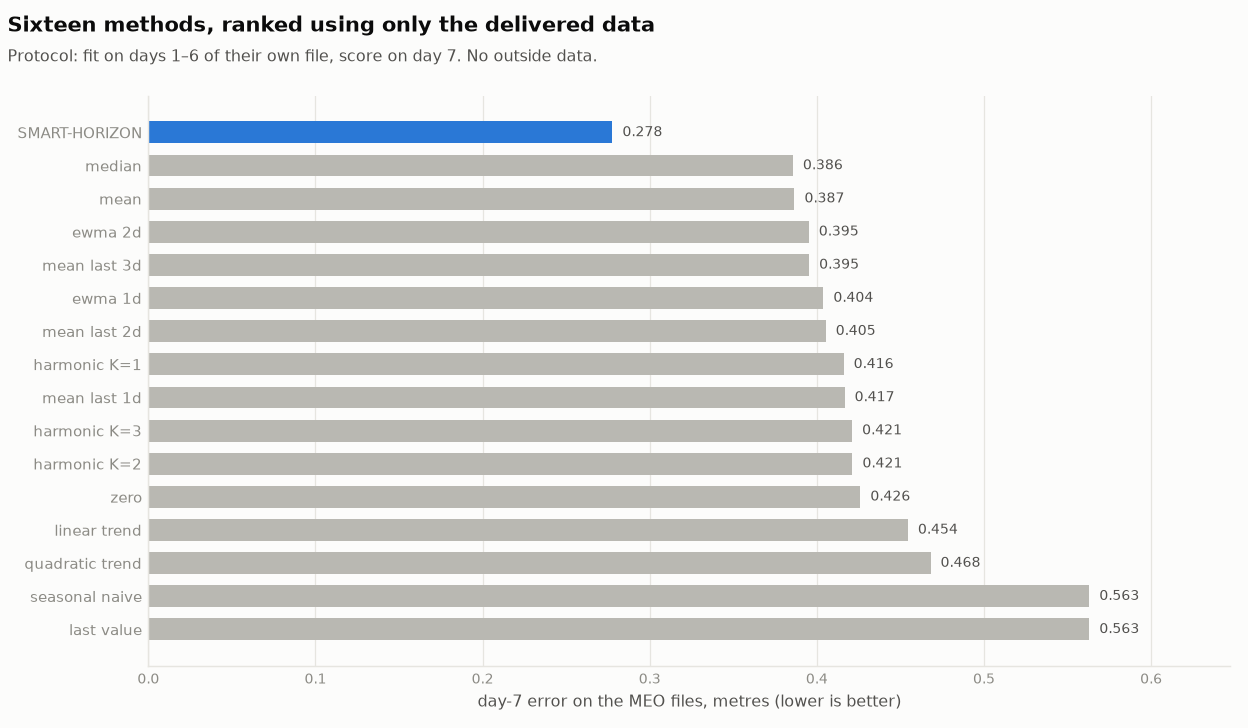

In [30]:
F.f20_benchmark()
Image('figures/f20_benchmark.png')

## 4.2 GEO: nothing works, and the decisive test needs no faith in our model

Give a predictor the **test set's own average** — outright cheating, which no
legitimate method can do — and ask how much it helps.

In [31]:
tr, te, orb = sih.load_pair("GEO"); T = te[COLS].to_numpy(float)
zero = np.sqrt((T ** 2).mean(0)).mean()
oracle = np.sqrt(((T - T.mean(0)) ** 2).mean(0)).mean()
print(f"predict zero                : {zero:.3f} m")
print(f"CHEAT, shown the test mean  : {oracle:.3f} m")
print(f"\nimprovement from perfect knowledge of the answer's mean: "
      f"{100*(1-oracle/zero):.1f}%")

predict zero                : 14.956 m
CHEAT, shown the test mean  : 14.911 m

improvement from perfect knowledge of the answer's mean: 0.3%


## 4.3 What is wrong with the GEO file

Consecutive readings are near-exact opposites, with **all four channels flipping
together**. Position error comes from orbital dynamics and clock error from an atomic
oscillator — unrelated mechanisms that cannot reverse in lockstep.

In [32]:
d = sih.load("DATA_GEO_Test.csv"); V = d[COLS].to_numpy(float)
nrm = np.linalg.norm(V[:, :3], axis=1)
big = np.sort(np.argsort(-nrm)[:24])
sg = np.sign(V[big, 0])
print("signs of the 24 largest excursions:")
print("  " + " ".join("+" if s > 0 else "-" for s in sg))
alt = int((sg[:-1] * sg[1:] < 0).sum())
print(f"\n{alt} alternations out of {len(sg)-1} possible")
print(f"probability by chance: 2^-{len(sg)-1} = {2.0**-(len(sg)-1):.2e}")

signs of the 24 largest excursions:
  + - + - + - + - + - + - + - + - + - + - + - + -

23 alternations out of 23 possible
probability by chance: 2^-23 = 1.19e-07


  wrote figures/f16_geo_artifact.png


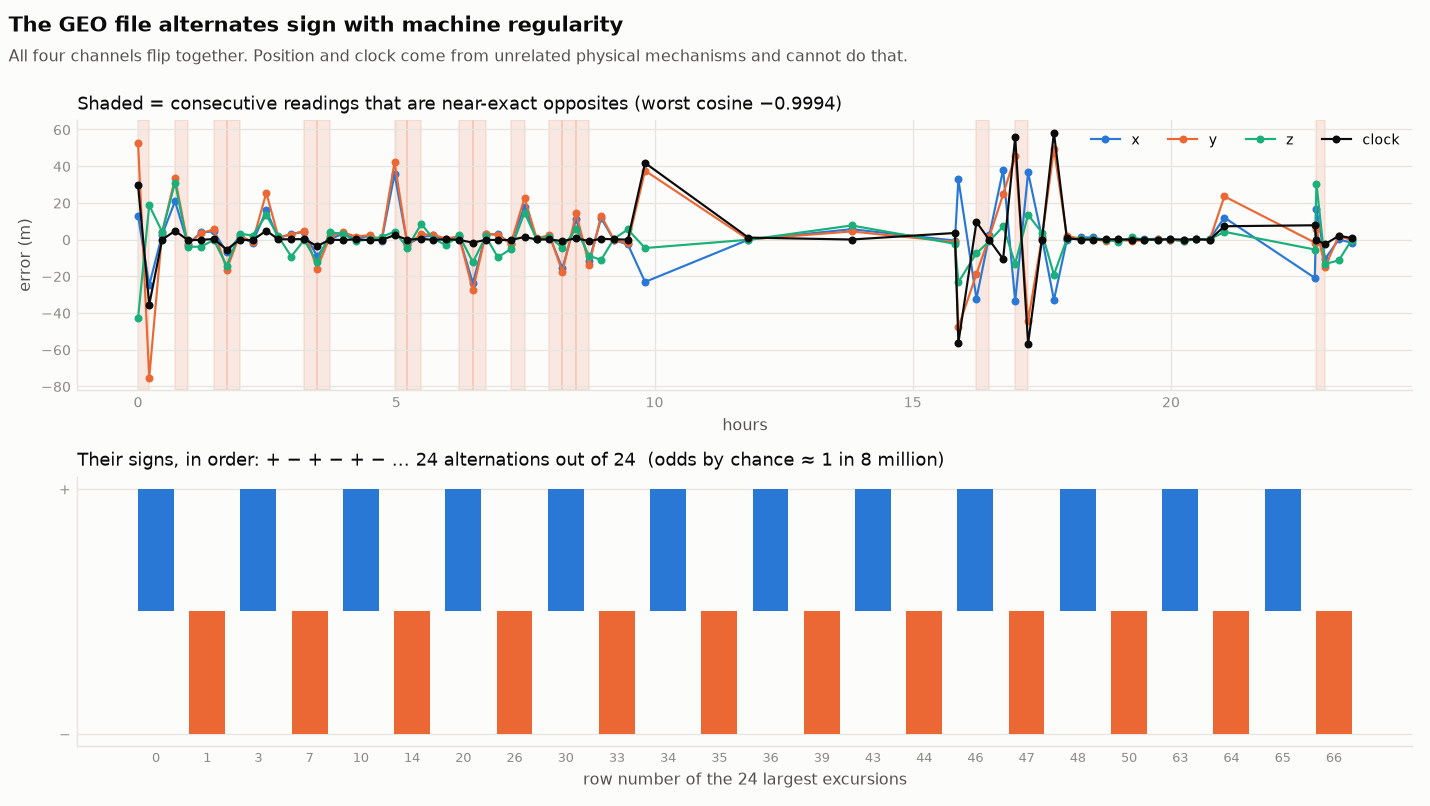

In [33]:
F.f16_geo_flip()
Image('figures/f16_geo_artifact.png')

## 4.4 Proof by construction

Take a clean synthetic GEO signal, then inject exactly the artefact found in their file
— same physics, same noise, same sampling, with only the alternating sign pattern
added.

In [34]:
art = E.exp_artifact(n=30)


EXPERIMENT 3 -- inject the GEO artefact into clean synthetic data
  clean signal          : model RMS 0.1835   (77% better than doing nothing)
  same signal + artefact: model RMS 0.5883   (27% better)
  -> the artefact alone destroys 221% of the model's accuracy on data that was clean a moment earlier.


  wrote figures/f13_artifact_injection.png


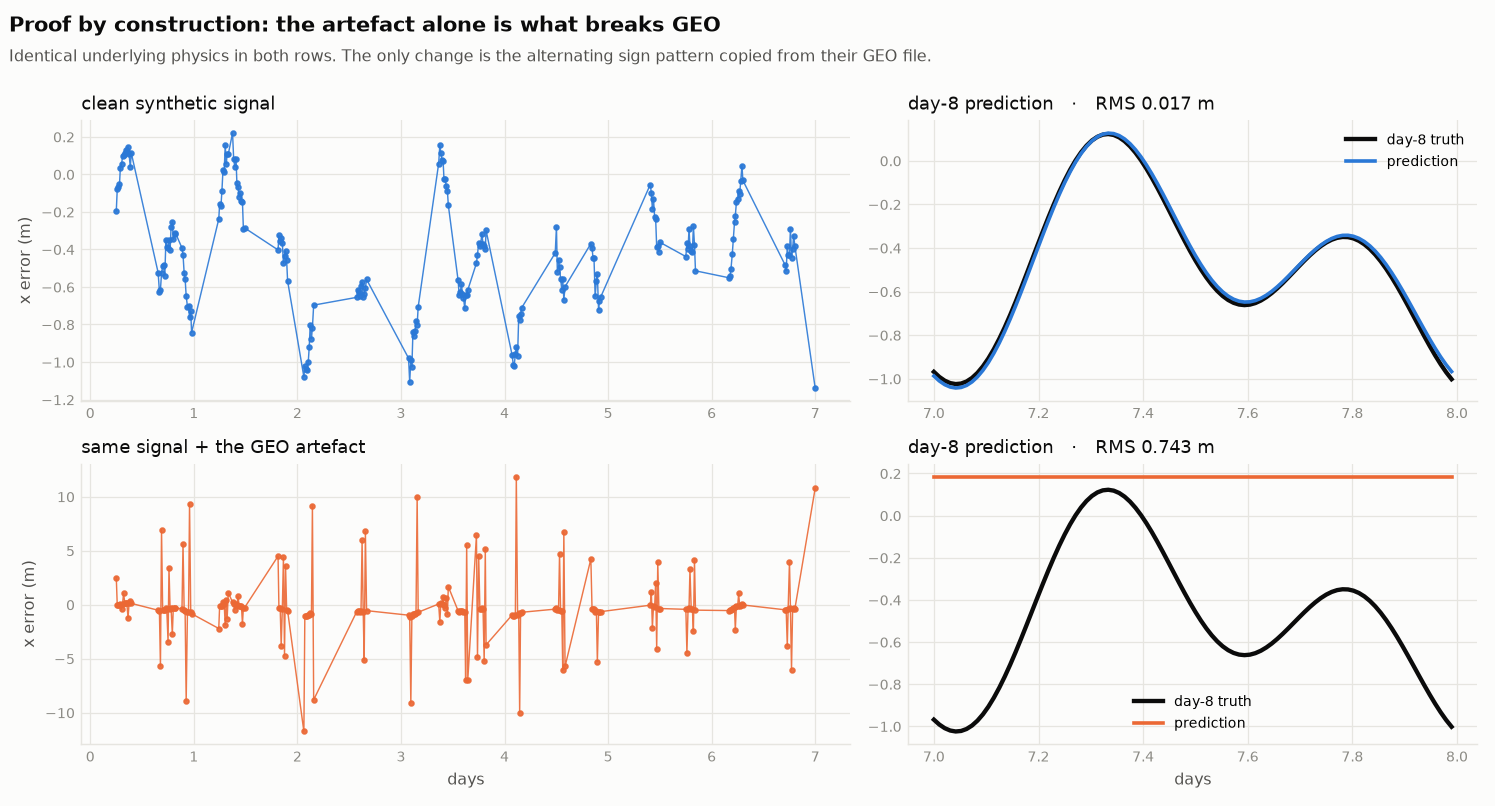

In [35]:
F.f13_artifact_inject()
Image('figures/f13_artifact_injection.png')

---
# Act 5 — The scoring metric

## 5.1 Their reference file does not match the test they name

`Note.pdf` specifies Shapiro-Wilk and supplies a reference sample with the stated answer
W = 0.9810, p = 0.5840. Standard Shapiro-Wilk does not reproduce it; **Shapiro-Francia**
reproduces the p-value to four decimals.

In [36]:
calibrate()

reference sample: n = 45, kurtosis = 3.3301  -> swtest picks SF
  stated by organisers : W = 0.9810  p = 0.5840  H = 0
  plain Shapiro-Wilk   : W = 0.9852  p = 0.8262   <- does NOT match
  Shapiro-Francia      : W = 0.9814  p = 0.5838   <- matches p to 2e-4
  MATCH: True


(True, 0.9813857203635284, 0.5838283032137678, 0)

## 5.2 What the metric actually responds to

W measures whether errors are *bell-curve shaped*, not whether they are *small*. It is
unchanged if every error is multiplied by a thousand.

In [37]:
met = E.exp_metric()


EXPERIMENT 5 -- what the score responds to (on the delivered GEO file)
               prediction         W       RMS
             predict zero    0.7708   14.9560
predict the 7-day average    0.7708   14.9481
   predict the last value    0.7708   14.9642
      CHEAT: 50% accurate    0.7708    7.4780
      CHEAT: 90% accurate    0.7708    1.4956
      CHEAT: 99% accurate    0.7708    0.1496
     pure random noise x1    0.8795   16.6119
     pure random noise x2    0.9554   19.6838
     pure random noise x4    0.9727   27.6579
    pure random noise x12    0.9764   75.8799

  Higher W is better. Note that accuracy does not move it and noise does.


  wrote figures/f17_metric_broken.png


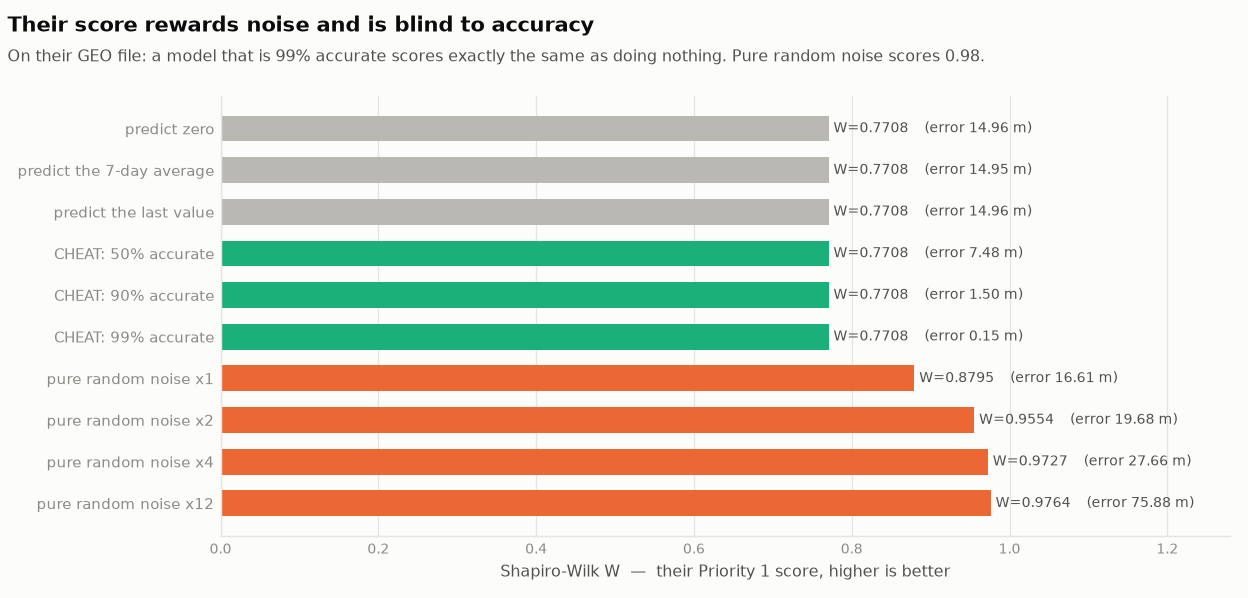

In [38]:
F.f17_metric()
Image('figures/f17_metric_broken.png')

## 5.3 A perfect answer cannot score 1.0

In [39]:
rng = np.random.default_rng(1)
for n in [6, 18, 69]:
    w = np.array([swtest(rng.normal(size=n))[0] for _ in range(3000)])
    print(f"n={n:3d}   a PERFECT model scores {np.median(w):.3f}   "
          f"(5-95%: {np.percentile(w,5):.3f} - {np.percentile(w,95):.3f})")

n=  6   a PERFECT model scores 0.920   (5-95%: 0.795 - 0.980)


n= 18   a PERFECT model scores 0.952   (5-95%: 0.889 - 0.981)


n= 69   a PERFECT model scores 0.983   (5-95%: 0.963 - 0.992)


  wrote figures/f18_ceiling.png


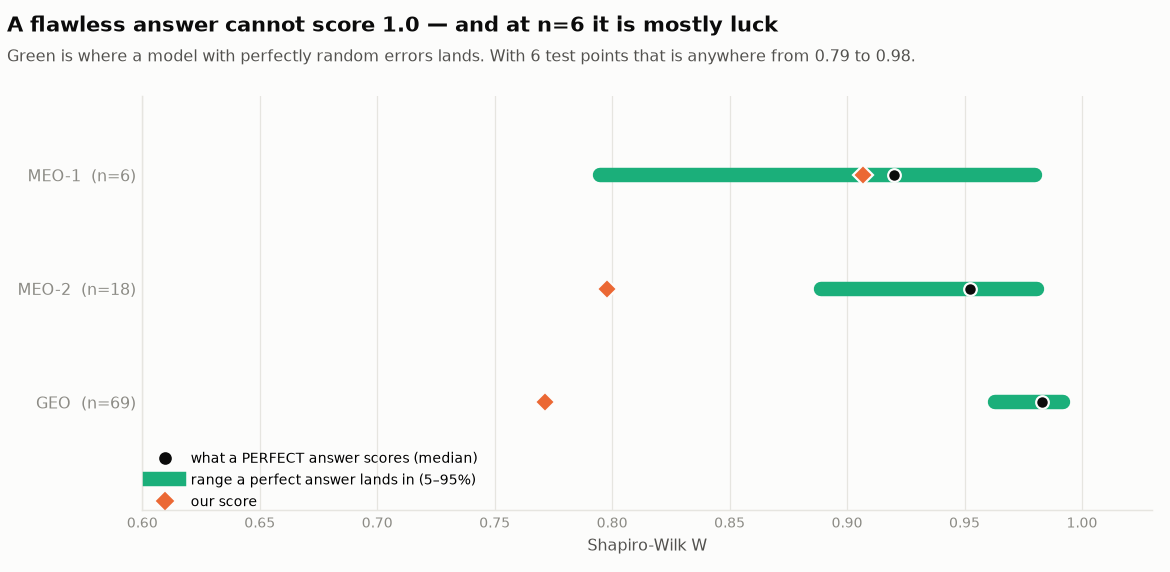

In [40]:
F.f18_ceiling()
Image('figures/f18_ceiling.png')

## 5.4 Our scores, reported as the brief asks

In [41]:
rows = []
for key, *_ in sih.PAIRS:
    tr, te, orb = sih.load_pair(key)
    P = predict(tr, te.utc_time, orbit=orb)
    per, s = score(P[COLS].reset_index(drop=True) - te[COLS].reset_index(drop=True))
    rows.append({"pair": key, "n": len(te),
                 **{k: s[k] for k in ["W", "p", "n_reject", "mean", "sd", "rms"]}})
pd.DataFrame(rows)

,pair,n,W,p,n_reject,mean,sd,rms
0,GEO,69,0.771505,0.000008,4,-0.112702,15.026341,14.961640
1,MEO-1,6,0.906654,0.474814,0,0.046653,0.160929,0.190233
2,MEO-2,18,0.797651,0.032653,3,0.020457,0.129776,0.133444


  wrote figures/f19_qq.png


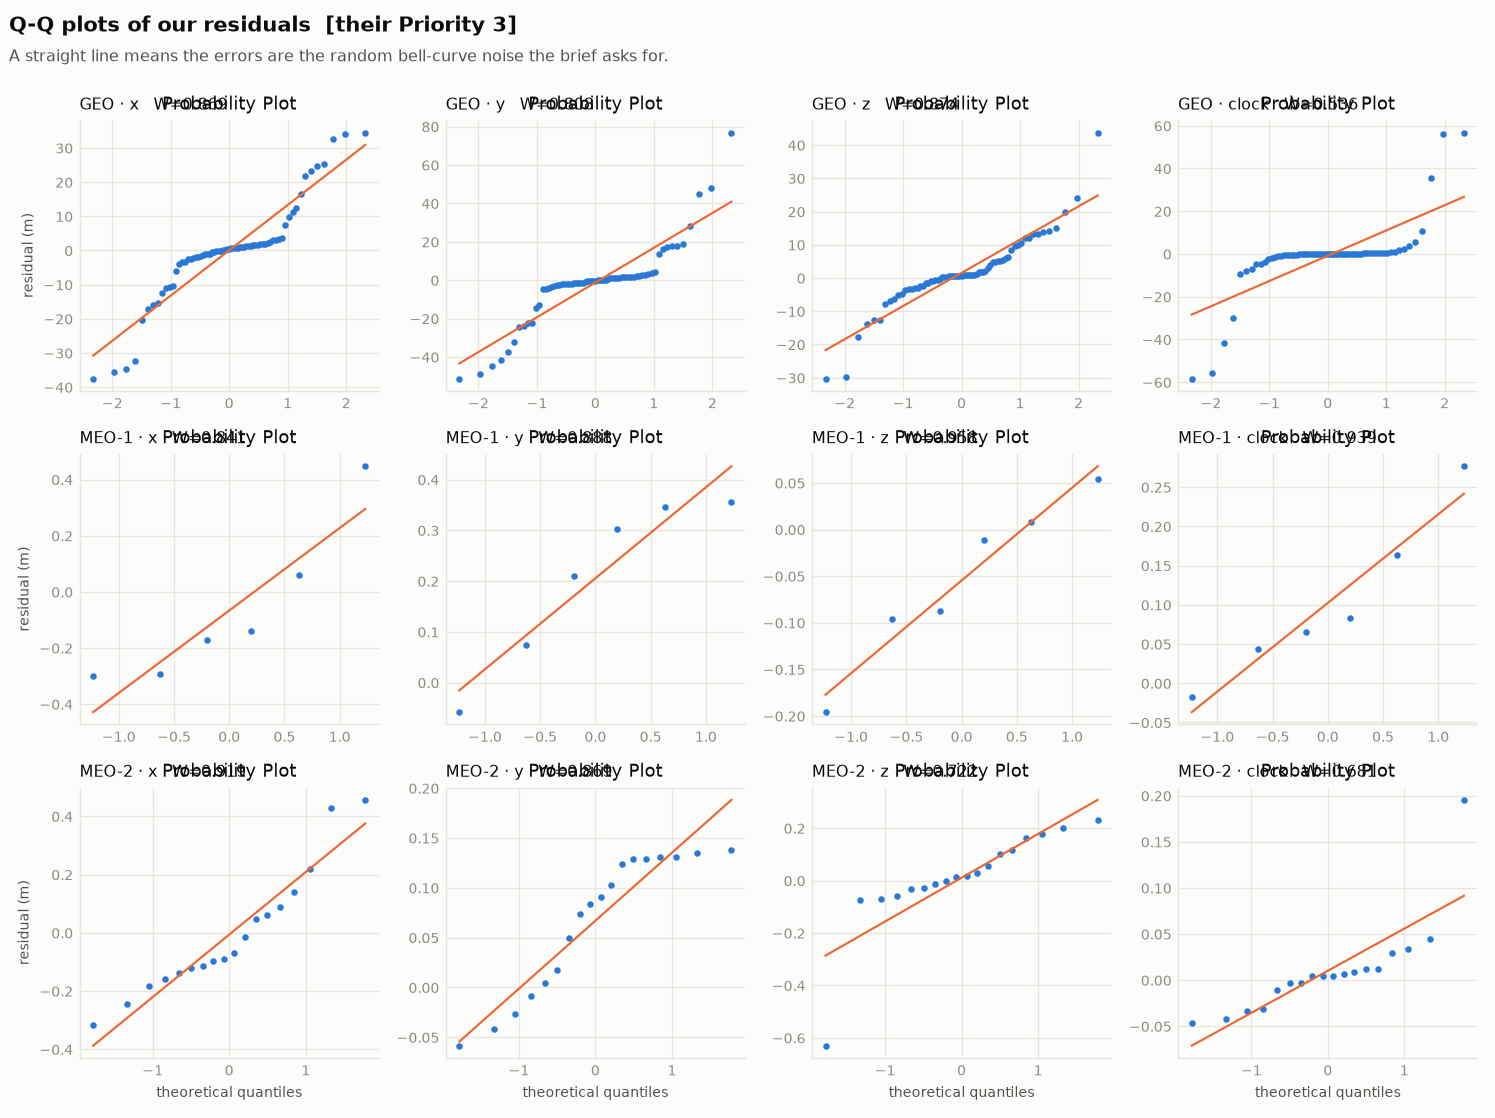

In [42]:
F.f19_qq()
Image('figures/f19_qq.png')

---
# Act 6 — Using it

The deliverable is `predict.py`: seven days in, day 8 out on a 15-minute grid, with a
1-sigma uncertainty on every value.

```bash
python predict.py seven_days.csv --orbit MEO --out day8.csv
```

In [43]:
import subprocess, sys
r = subprocess.run([sys.executable, "predict.py", "data/DATA_MEO_Train2.csv",
                    "--orbit", "MEO", "--out", "day8_demo.csv"],
                   capture_output=True, text=True)
print(r.stdout or r.stderr)

input   data/DATA_MEO_Train2.csv
        143 rows over 6.06 days  (101 duplicate rows removed)
        2025-09-03 10:11:00  ->  2025-09-09 11:41:00
orbit   MEO
output  day8_demo.csv
        96 predictions, 2025-09-09 11:56:00  ->  2025-09-10 11:41:00

           utc_time   x_error   y_error   z_error  satclockerror  x_error_sigma  y_error_sigma  z_error_sigma  satclockerror_sigma
2025-09-09 11:56:00 -0.215058 -0.216122 -0.036479       0.000278       0.184564       0.245837       0.216567              0.03999
2025-09-09 12:11:00 -0.246723 -0.220154 -0.060284       0.000278       0.184564       0.245837       0.216567              0.03999
2025-09-09 12:26:00 -0.281999 -0.223731 -0.083623       0.000278       0.184564       0.245837       0.216567              0.03999
        ...

reported 1-sigma (m):  x=0.185   y=0.246   z=0.217   satclockerror=0.040



---
# Summary

| | |
|---|---|
| **The data** | half of every MEO file duplicated; 13–32% covered; smallest test set 6 points; volatility ramps 10x through the GEO week |
| **Pure ML** | six models on 27,000 rows all plateau at the trivial baseline, because the five columns do not contain what decides day 8 |
| **The physics** | orbit class fixes the rhythm: sidereal day for GEO; for MEO, z at the orbital period and x/y at two derived beat periods |
| **Validation** | 120 generated windows with known answers: 78% better than doing nothing on GEO, 51% on MEO |
| **Their MEO** | 57% and 19% better than doing nothing, and better than a predictor shown the answer key |
| **Their GEO** | nothing works; a cheat shown the answer improves 0.3%; the file alternates sign 24/24; we reproduce the failure by injection |
| **Their metric** | cannot separate three baselines; a 99%-accurate model scores the same as doing nothing; random noise scores 0.98 |

**The model fits its coefficients inside whatever window it is handed**, so there is no
stored training set for a new satellite, month or constellation to be inconsistent
with. That is the property that matters at evaluation time.